# I'm gonna run a test model here before diving deep into the ultimate model

## I. Introduction
This document only focus on a simple ML model using lightgbm to test the dataset.
I will note my progress making and trying simple model (only use libraries and modules) step-by-step.


## II, Tutorial
### Step 1: Import library.

In [167]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import log_evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report
from sklearn.preprocessing import LabelEncoder
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

### Step 2:Prepare the dataset

In [168]:
file_path = r'G:\url-analysis\src\data\malicious_phish_processed.csv'
url_data = pd.read_csv(file_path, encoding_errors='ignore')
url_data.info()

print(url_data.isnull().sum())
print("\nPhân phối nhãn:")
print(url_data['type'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 653490 entries, 0 to 653489
Data columns (total 66 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   url                               653490 non-null  str    
 1   type                              653490 non-null  str    
 2   url length                        653490 non-null  int64  
 3   number_of_part                    653490 non-null  int64  
 4   has_scheme                        653490 non-null  int64  
 5   has_netloc                        653490 non-null  int64  
 6   has_path                          653490 non-null  int64  
 7   has_params                        653490 non-null  int64  
 8   has_query                         653490 non-null  int64  
 9   has_fragment                      653490 non-null  int64  
 10  has_username                      653490 non-null  int64  
 11  has_password                      653490 non-null  int64  
 12 

### Step 3: split the dataset, X is the set of features used to test, y is the label

In [169]:
X = pd.DataFrame(url_data).drop(columns = ['url', 'type'])
print(X.head())

# y is the tag for supervised learning
y = url_data.type
print(y)

   url length  number_of_part  has_scheme  has_netloc  has_path  has_params  \
0          16               1           0           1         0           0   
1          35               2           0           1         1           0   
2          31               2           0           1         1           0   
3          88               4           1           1         1           0   
4         235               4           1           1         1           0   

   has_query  has_fragment  has_username  has_password  ...  download_param  \
0          0             0             0             0  ...               0   
1          0             0             0             0  ...               0   
2          0             0             0             0  ...               0   
3          1             0             0             0  ...               0   
4          1             0             0             0  ...               0   

   free_host  free_host_download  suspicious suffi

### Step 4: write loss_function

In [170]:
def loss_function():
    pass
def gradient_descent():
    pass
def hessian():
    pass

### Step 5: split X, y to X_train, X_test, y_train, y_test to train and test using LightGBM model

In [171]:
le = LabelEncoder()
encoded_y = le.fit_transform(y)
print(encoded_y)


X_temp, X_test, y_temp, y_test = train_test_split(X, encoded_y, test_size = 0.15,stratify=encoded_y ,random_state = 42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size = 0.177,stratify=y_temp ,random_state = 42)
print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

params = {
    'objective' : 'multiclass',
    'class_weight' : 'balanced',
    'n_estimators' : 3000,
    'num_class' : 4,
    'boosting_type' : 'gbdt',
    'learning_rate' : 0.01,
    'verbose' : -1,
    'random_state' : 42,
    'colsample_bytree' : 0.75,
    'max_depth' : 7,
    'num_leaves' : 32,
    'min_data_in_leaf' : 30,
    'early_stopping_rounds' : 50,
    'n_jobs' : -1
}

model_classification = lgb.LGBMClassifier(**params)

callbacks = [lgb.early_stopping(stopping_rounds=50,verbose=True), lgb.log_evaluation(100)]
model_classification.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    callbacks=callbacks,
    eval_metric=['multi_logloss', 'auc_mu']
)

[3 0 0 ... 3 3 3]
Train: 457148 | Validation: 98318 | Test: 98024
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.468284	valid_0's auc_mu: 0.988851
[200]	valid_0's multi_logloss: 0.283119	valid_0's auc_mu: 0.991472
[300]	valid_0's multi_logloss: 0.225001	valid_0's auc_mu: 0.993107
[400]	valid_0's multi_logloss: 0.200873	valid_0's auc_mu: 0.994021
[500]	valid_0's multi_logloss: 0.187053	valid_0's auc_mu: 0.994618
[600]	valid_0's multi_logloss: 0.177843	valid_0's auc_mu: 0.995028
[700]	valid_0's multi_logloss: 0.170591	valid_0's auc_mu: 0.995342
[800]	valid_0's multi_logloss: 0.164725	valid_0's auc_mu: 0.995589
[900]	valid_0's multi_logloss: 0.159904	valid_0's auc_mu: 0.995798
[1000]	valid_0's multi_logloss: 0.155716	valid_0's auc_mu: 0.995967
[1100]	valid_0's multi_logloss: 0.152279	valid_0's auc_mu: 0.996102
[1200]	valid_0's multi_logloss: 0.149116	valid_0's auc_mu: 0.99622
[1300]	valid_0's multi_logloss: 0.146451	valid_0's auc_mu: 0.996324

,num_leaves,32
,max_depth,7
,learning_rate,0.01
,n_estimators,3000
,objective,'multiclass'
,class_weight,'balanced'
,colsample_bytree,0.75
,random_state,42
,n_jobs,-1
,num_class,4
,verbose,-1


In [172]:
y_pred = model_classification.predict_proba(X_test)
y_pred_classes = np.argmax(y_pred, axis = 1)


print("=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ===")
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Độ chính xác (Accuracy): {accuracy:.4f}\n")

# In ra Classification Report chi tiết (Precision, Recall, F1-score)
# Sử dụng le.classes_ để map ngược lại tên chuỗi ban đầu (phishing, benign, malware, defacement)
print("Báo cáo phân loại chi tiết:")
print(classification_report(y_test,y_pred_classes, target_names=le.classes_))

# 3. Lưu mô hình (vì ở step 2 bạn đã import joblib)
model_filename = 'lgb_url_classifier.pkl'
joblib.dump(model_classification, model_filename)
print(f"Đã lưu mô hình thành công tại: {model_filename}")

=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ===
Độ chính xác (Accuracy): 0.9657

Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

      benign       0.99      0.97      0.98     64216
  defacement       0.97      0.99      0.98     14469
     malware       0.97      0.95      0.96      4878
    phishing       0.87      0.92      0.89     14461

    accuracy                           0.97     98024
   macro avg       0.95      0.96      0.95     98024
weighted avg       0.97      0.97      0.97     98024

Đã lưu mô hình thành công tại: lgb_url_classifier.pkl


### Step 6: Display the confusion matrix

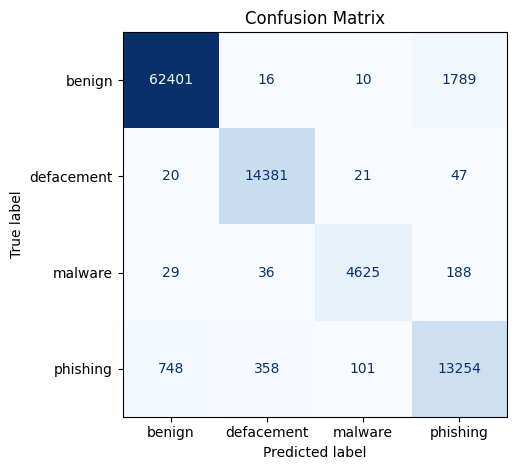

In [179]:
gcm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### Step 7: Check the importance of feature

['url', 'type', 'url length', 'number_of_part', 'has_scheme', 'has_netloc', 'has_path', 'has_params', 'has_query', 'has_fragment', 'has_username', 'has_password', 'has_port', 'has_subdomain', 'has_domain', 'has_suffix', 'netloc_length', 'path_length', 'query_length', 'fragment_length', 'subdomain_length', 'domain_length', 'url_entropy', 'netloc_entropy', 'path_entropy', 'query_entropy', 'subdomain_entropy', 'domain_entropy', 'number_of_subdomain', 'hyphen_in_subdomain', 'hyphen_in_domain', 'unicode', 'punycode', 'at_sign_in_netloc', 'slash_in_path', 'dot_in_path', 'strange_in_query', 'equal_in_query', 'ampersand_in_query', 'normalized_levenshtein_domain', 'normalized_levenshtein_subdomain', 'random_domain_check', 'random_subdomain_check', 'number_ratio_domain', 'number_ratio_subdomain', 'repeated_domain_check', 'repeated_path_check', 'repeated_url_check', 'longest_repeated_chain', 'ip_domain', 'suspicious_key_domain', 'suspicious_key_subdomain', 'suspicious_key_path', 'suspicious_key_q

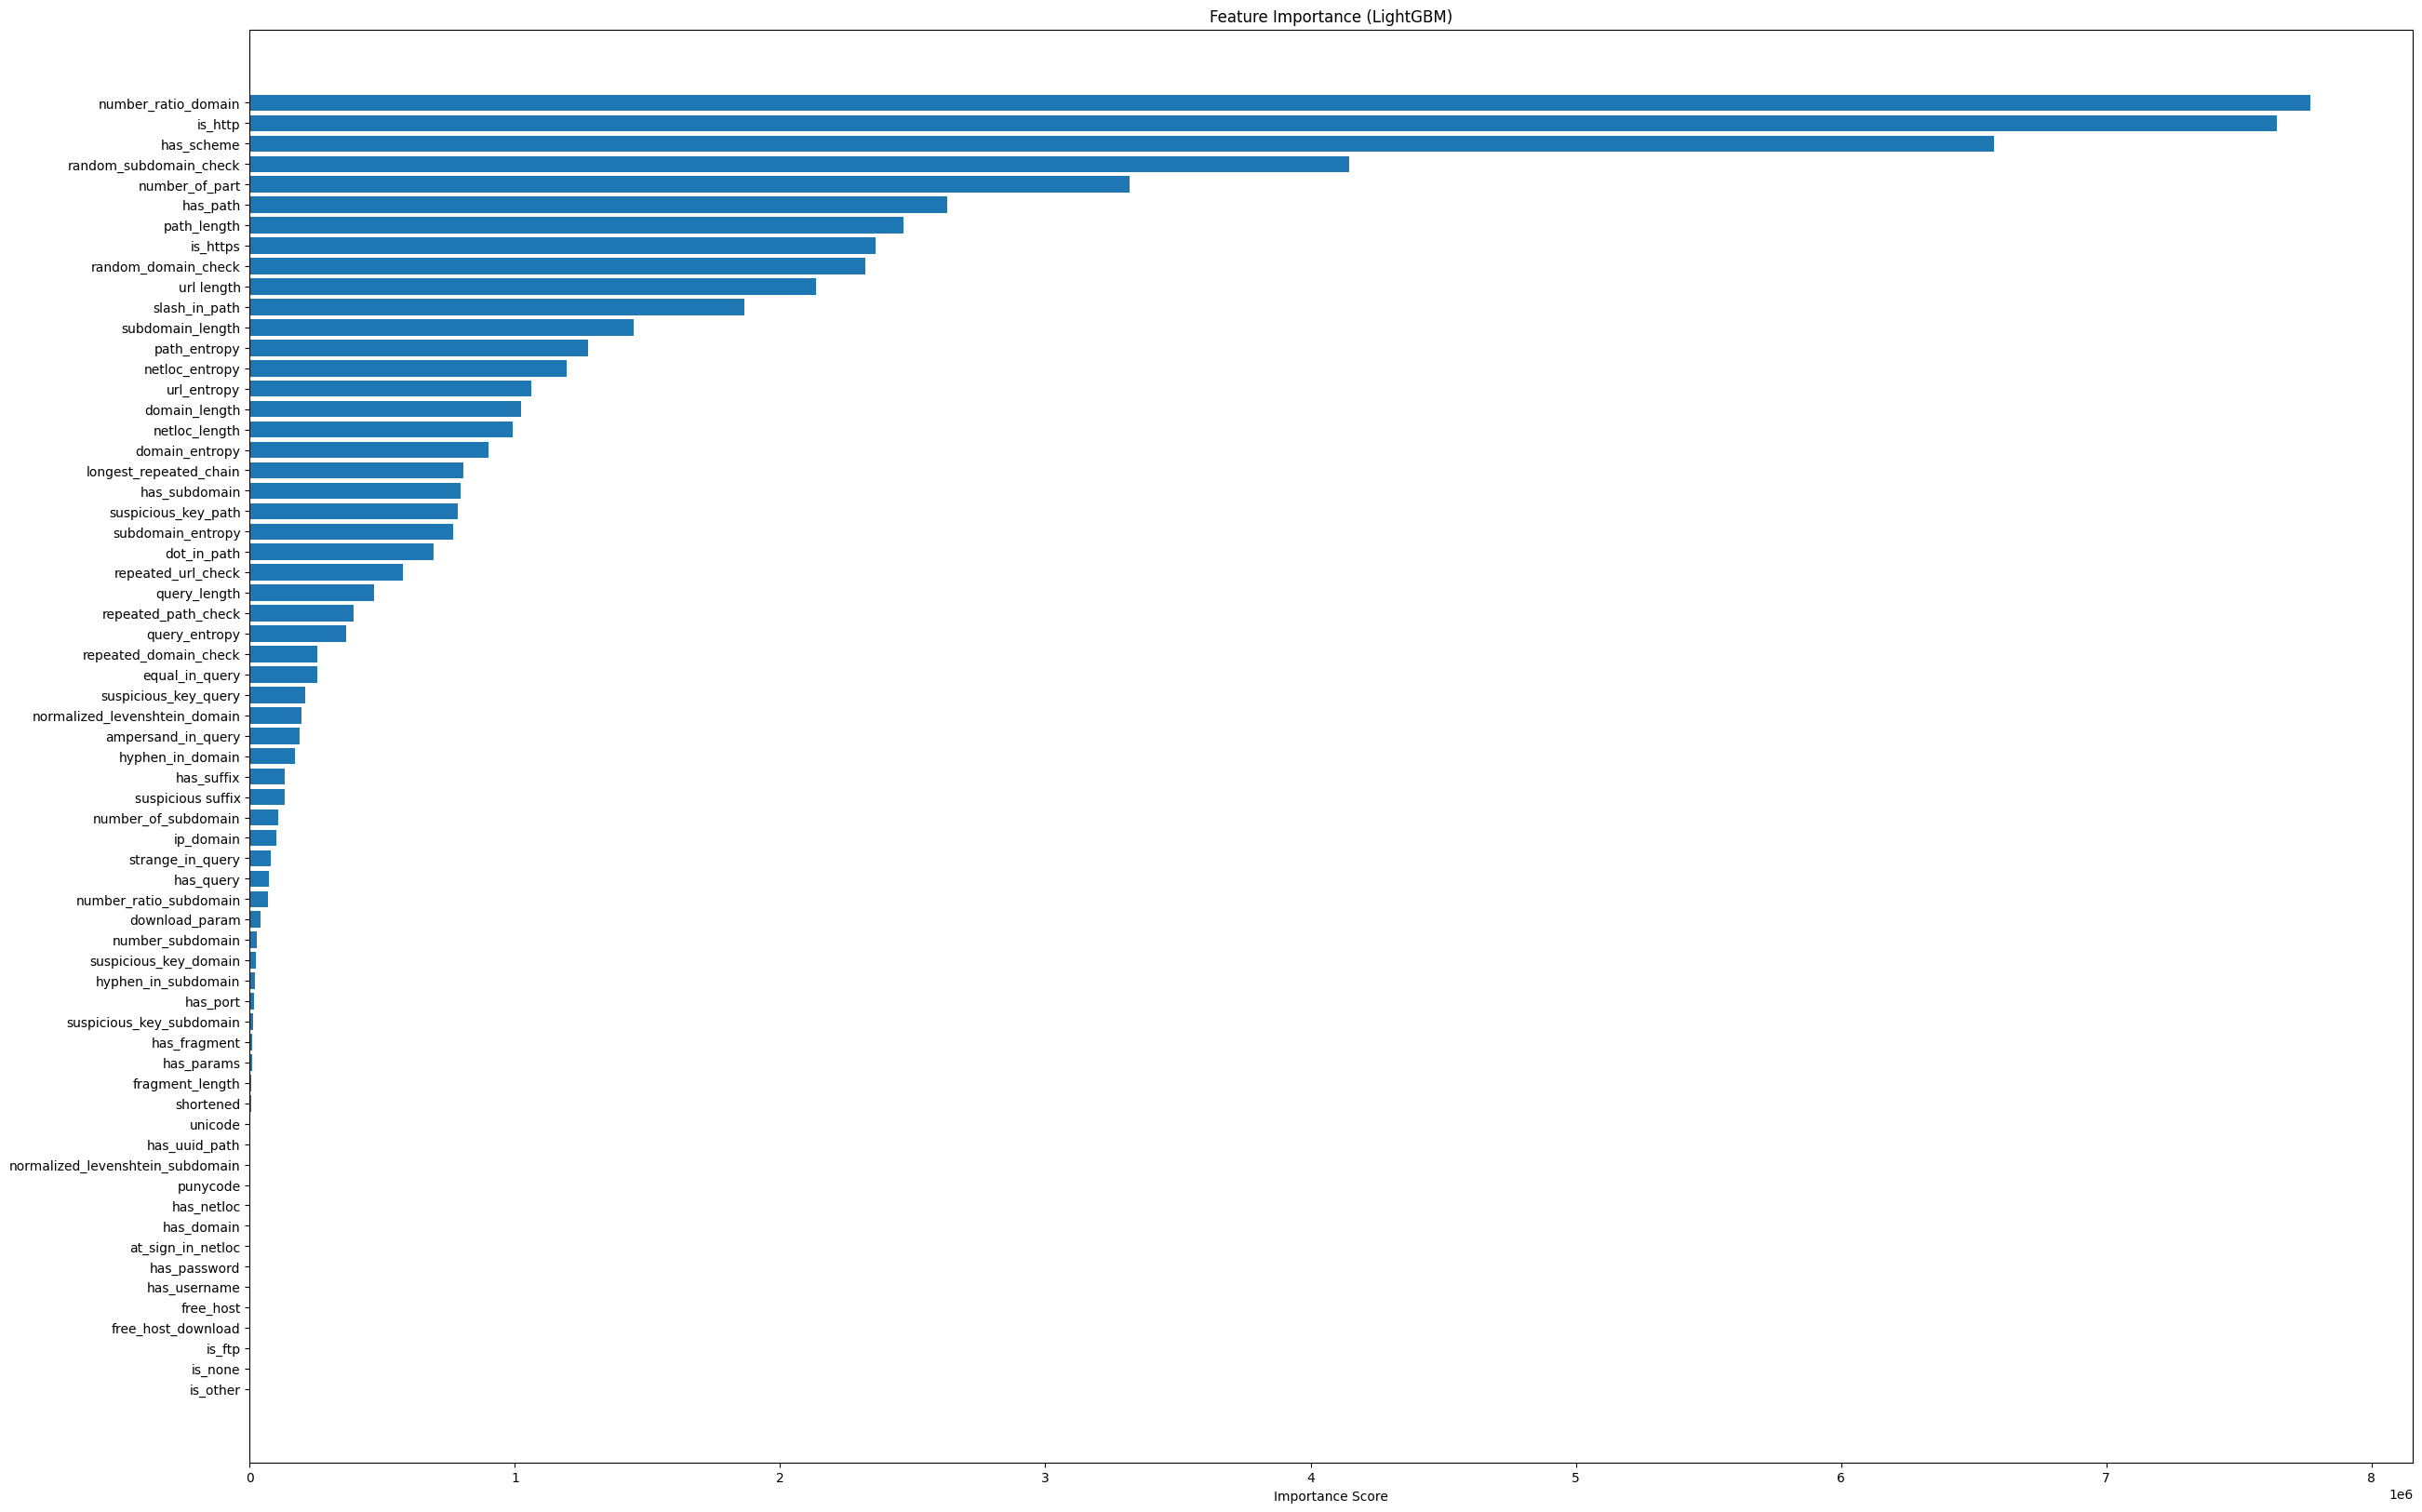

In [174]:
col_list = url_data.columns.tolist()
print(col_list)

importances = model_classification.booster_.feature_importance(importance_type = 'gain')
importance_df = pd.DataFrame(
    {
        "feature" : X.columns,
        "importance" : importances
    }
).sort_values(by="importance", ascending = False)
print(importance_df)

plt.figure(figsize=(30,20))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (LightGBM)")
plt.xlabel("Importance Score")
plt.show()